In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_score, silhouette_samples

In [2]:
# load in 640D embeds
embeds = np.load('data/embeddings.npz')

In [3]:
SAVED = True
# get family atlas data (either from local csv or from database), defaults to local, but set SAVED=False to pull from database
if SAVED:
    family_df = pd.read_csv('data/family_atlas.csv')
else:
    DB = {
        "host":     "petadex.ccz9y6yshbls.us-east-1.rds.amazonaws.com",
        "port":     5432,
        "database": "petadex",
        "user":     "readonly_user",
        "password": "petadex",
    }

    conn = psycopg2.connect(**DB)
    cur  = conn.cursor()
    cur.execute("""
                SELECT * 
                FROM family_atlas
                JOIN enzyme_taxonomy ON family_atlas.family_id = enzyme_taxonomy.family
                WHERE enzyme_taxonomy.family_pid = 100.0;
                """)
    data = cur.fetchall()
    family_df = pd.DataFrame(data, columns=[desc[0] for desc in cur.description])
    family_df.to_csv('data/family_atlas.csv', index=False)

In [49]:
# merge embeddings with domain info, use names_df for pretty names, and fill in missing domains with "Unknown"
embeds_df = pd.DataFrame(embeds['embeddings'], columns=[f'emb_{i}' for i in range(embeds['embeddings'].shape[1])])
embeds_df['family_id'] = embeds['family_ids']

components_df = family_df[['component', 'family_id']]
merged_df = embeds_df.merge(components_df, on='family_id')
names_df = pd.read_csv('data/component.summary.tsv', sep='\t')

merged_df = merged_df.merge(names_df[['component', 'domain']], on='component', how='left')
merged_df["domain"] = merged_df["domain"].fillna("Unknown")
merged_df.drop(columns=['component', 'family_id'], inplace=True, errors='ignore')

In [51]:
# Calculate silhouette scores using domain labels
X = merged_df.drop(columns=['domain']).values
labels = merged_df['domain'].values
silhouette_avg = silhouette_score(X, labels, metric='cosine')
sample_sil = silhouette_samples(X, labels, metric='cosine')

In [52]:
# Create a DataFrame for silhouette scores and compute mean/median silhouette score per cluster
sil_df = pd.DataFrame({
    'cluster': labels,
    'silhouette': sample_sil
})

cluster_sil = (
    sil_df.groupby('cluster', as_index=False)['silhouette']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

In [53]:
print(f"Overall silhouette: {silhouette_avg:.4f}")
display(cluster_sil)

Overall silhouette: 0.0315


,cluster,mean,median,count
10,oxygenase-like,0.585837,0.616122,61
5,L-amino peptidase D-ALA esterase/amidase,0.441803,0.477983,120
3,Cupredoxins - blue copper,0.393000,0.422928,612
1,Amidase signature,0.322357,0.357263,3897
7,Uridase-like,0.283369,0.288355,93
6,Trypsin-like,0.239686,0.349584,2416
2,Arylesterase,0.239673,0.284594,866
4,DD-peptidase/beta-lactamase,0.197455,0.230254,9750
9,cytochrome c-like,0.130809,0.163143,61
8,cyclase-like,0.000000,0.000000,1


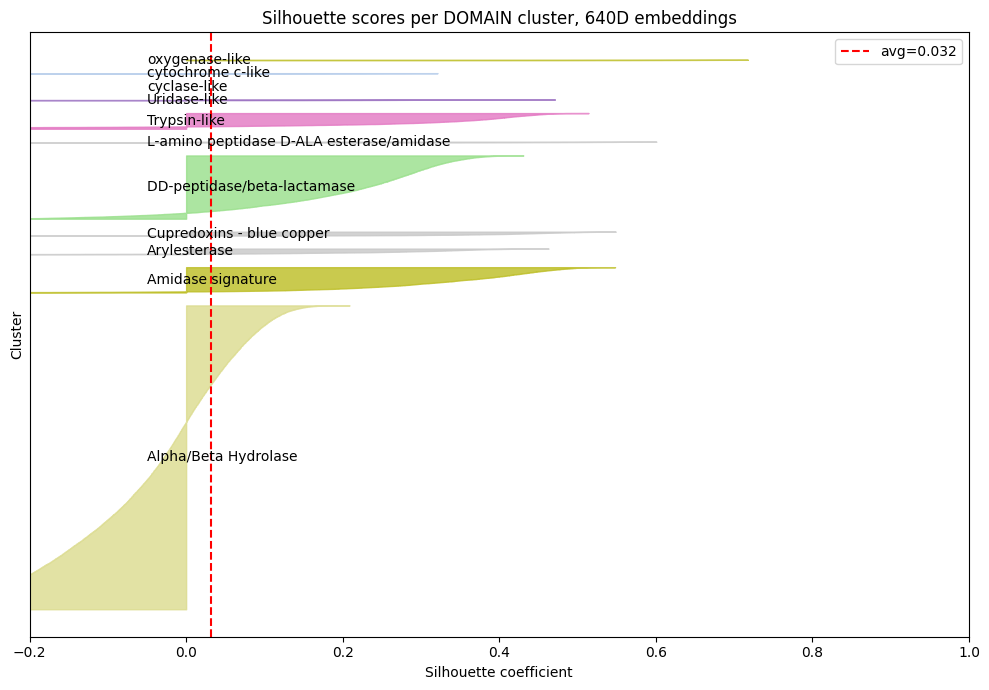

In [55]:
unique_clusters = np.unique(labels)
fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for cluster in unique_clusters:
    vals = np.sort(sample_sil[labels == cluster])
    size = vals.shape[0]
    y_upper = y_lower + size

    color = plt.cm.tab20(hash(cluster) % 20)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, vals,
        facecolor=color, edgecolor=color, alpha=0.8
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(cluster), va='center')
    y_lower = y_upper + 2000  # gap between clusters

ax.axvline(x=silhouette_avg, color='red', linestyle='--', label=f'avg={silhouette_avg:.3f}')
ax.set_title('Silhouette scores per DOMAIN cluster, 640D embeddings')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.set_xlim([-0.2, 1.0])
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [56]:
# merge embeddings with components this time, use names_df for pretty names, and fill in missing domains with "Unknown"
embeds_df = pd.DataFrame(embeds['embeddings'], columns=[f'emb_{i}' for i in range(embeds['embeddings'].shape[1])])
embeds_df['family_id'] = embeds['family_ids']

components_df = family_df[['component', 'family_id']]
merged_df = embeds_df.merge(components_df, on='family_id')
merged_df = merged_df.drop(columns=['family_id'])

In [57]:
# Calculate silhouette scores using component labels
X = merged_df.drop(columns=['component']).values
labels = merged_df['component'].values
silhouette_avg = silhouette_score(X, labels, metric='cosine')
sample_sil = silhouette_samples(X, labels, metric='cosine')

In [58]:
sil_df = pd.DataFrame({
    'cluster': labels,
    'silhouette': sample_sil
})

cluster_sil = (
    sil_df.groupby('cluster', as_index=False)['silhouette']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

In [59]:
print(f"Overall silhouette: {silhouette_avg:.4f}")
display(cluster_sil)

cluster_sil.to_csv('component_silhouette.csv')

Overall silhouette: -0.0355


,cluster,mean,median,count
14,16,0.551679,0.580137,61
8,9,0.438867,0.477983,120
6,7,0.418583,0.525377,7
32,34,0.341242,0.411018,19
12,14,0.302851,0.330812,612
2,3,0.293902,0.387534,122
7,8,0.289229,0.327368,599
10,11,0.283543,0.359240,2175
35,37,0.268648,0.305095,99
9,10,0.224950,0.256742,3897


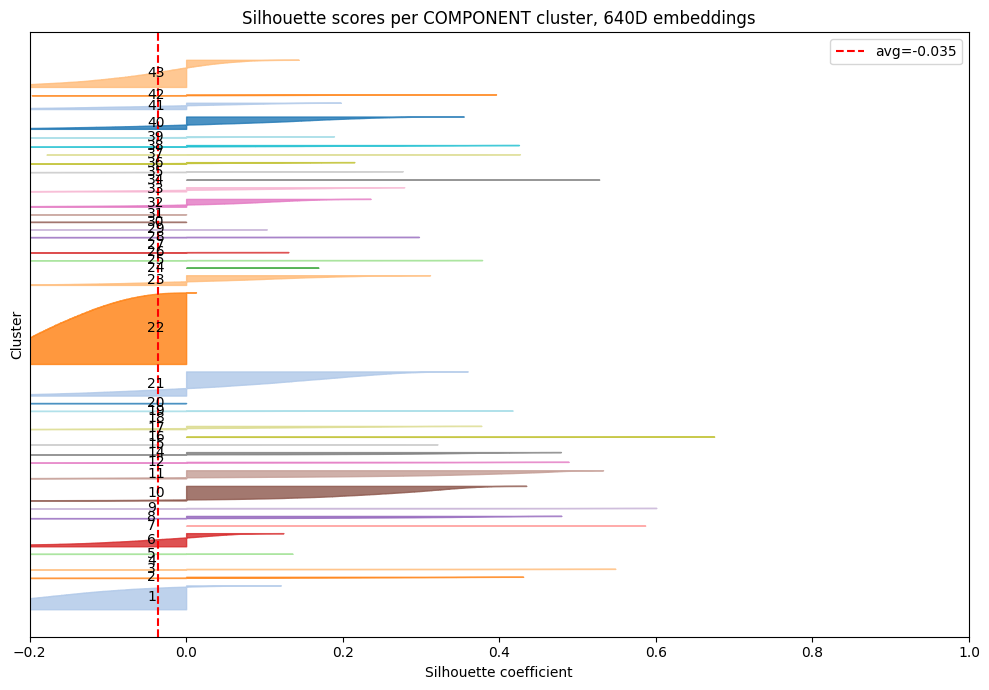

In [60]:
unique_clusters = np.unique(labels)
fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for cluster in unique_clusters:
    vals = np.sort(sample_sil[labels == cluster])
    size = vals.shape[0]
    y_upper = y_lower + size

    color = plt.cm.tab20(hash(cluster) % 20)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, vals,
        facecolor=color, edgecolor=color, alpha=0.8
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(cluster), va='center')
    y_lower = y_upper + 2000  # gap between clusters

ax.axvline(x=silhouette_avg, color='red', linestyle='--', label=f'avg={silhouette_avg:.3f}')
ax.set_title('Silhouette scores per COMPONENT cluster, 640D embeddings')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.set_xlim([-0.2, 1.0])
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [4]:
# domain wise silhouette scores using the 2D UMAP data
df = pd.read_csv('data/family_atlas.csv')
df = df[["umap_x", "umap_y", "component"]]
names_df = pd.read_csv('data/component.summary.tsv', sep='\t')

df = df.merge(names_df[['component', 'domain']], on='component', how='left')
df = df.drop(columns=['component'])

In [5]:
labels = df['domain'].values
X = df[['umap_x', 'umap_y']].values

silhouette_avg = silhouette_score(X, labels)
sample_sil = silhouette_samples(X, labels)

In [6]:
sil_df = pd.DataFrame({
    'cluster': labels,
    'silhouette': sample_sil
})

cluster_sil = (
    sil_df.groupby('cluster', as_index=False)['silhouette']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)
print(f"Overall silhouette: {silhouette_avg:.4f}")
display(cluster_sil)

Overall silhouette: 0.1824


,cluster,mean,median,count
10,oxygenase-like,0.997084,0.997581,61
5,L-amino peptidase D-ALA esterase/amidase,0.938953,0.960247,120
2,Arylesterase,0.875191,0.897077,866
3,Cupredoxins - blue copper,0.862502,0.877858,612
7,Uridase-like,0.829268,0.910597,93
4,DD-peptidase/beta-lactamase,0.745276,0.775189,9750
1,Amidase signature,0.725315,0.762394,3897
6,Trypsin-like,0.681451,0.796308,2416
8,cyclase-like,0.000000,0.000000,1
0,Alpha/Beta Hydrolase,-0.030324,0.154603,46853


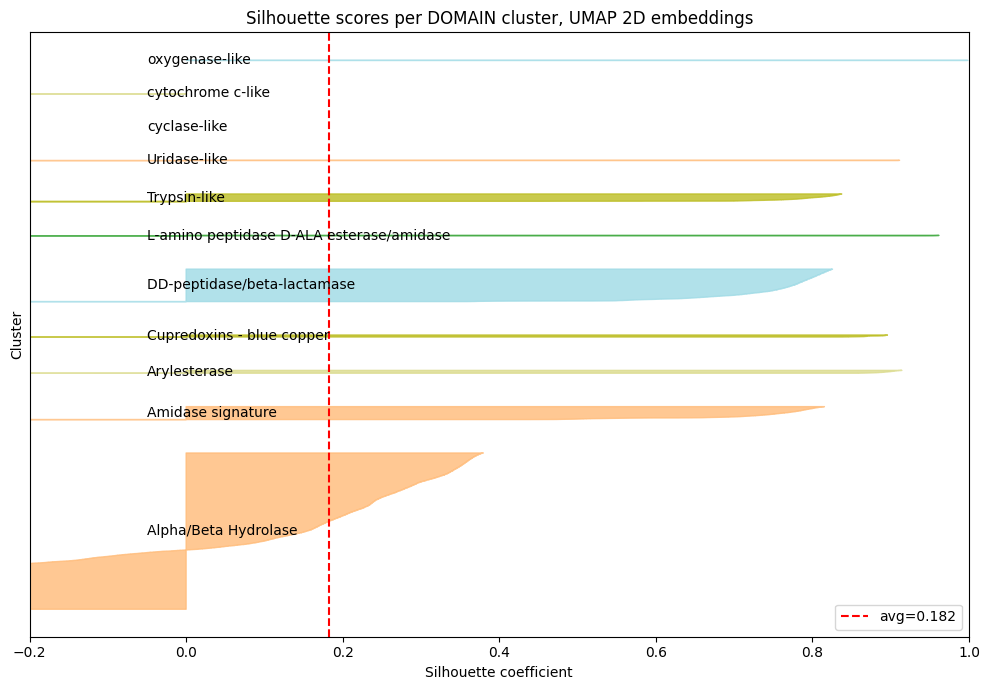

In [7]:
unique_clusters = np.unique(labels)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for cluster in unique_clusters:
    vals = np.sort(sample_sil[labels == cluster])
    size = vals.shape[0]
    y_upper = y_lower + size

    color = plt.cm.tab20(hash(cluster) % 20)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, vals,
        facecolor=color, edgecolor=color, alpha=0.8
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(cluster), va='center')
    y_lower = y_upper + 10000  # gap between clusters

ax.axvline(x=silhouette_avg, color='red', linestyle='--', label=f'avg={silhouette_avg:.3f}')
ax.set_title('Silhouette scores per DOMAIN cluster, UMAP 2D embeddings')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.set_xlim([-0.2, 1.0])
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [8]:
# get a list of outliers, defined as those with silhouette score < -0.1, and save to csv
outliers_df = sil_df[sil_df['silhouette'] < -0.1]
outliers_df.to_csv('domain_outliers.csv', index=False)

In [65]:
# component wise silhouette scores using the 2D UMAP data
df = pd.read_csv('data/family_atlas.csv')
df = df[["umap_x", "umap_y", "component"]]
names_df = pd.read_csv('data/component.summary.tsv', sep='\t')

df = df.merge(names_df[['component', 'domain']], on='component', how='left')
df = df.drop(columns=['domain'])

In [66]:
labels = df['component'].values
X = df[['umap_x', 'umap_y']].values

silhouette_avg = silhouette_score(X, labels)
sample_sil = silhouette_samples(X, labels)

In [69]:
sil_df = pd.DataFrame({
    'cluster': labels,
    'silhouette': sample_sil
})

cluster_sil = (
    sil_df.groupby('cluster', as_index=False)['silhouette']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)
print(f"Overall silhouette: {silhouette_avg:.4f}")
display(cluster_sil)

Overall silhouette: 0.0547


,cluster,mean,median,count
14,16,0.997084,0.997581,61
8,9,0.907330,0.938441,120
15,17,0.857998,0.885774,866
12,14,0.843089,0.863059,612
36,38,0.792325,0.834192,462
10,11,0.754617,0.803698,2175
38,40,0.747631,0.796359,3288
9,10,0.712367,0.749953,3897
17,19,0.676982,0.783767,93
1,2,0.621559,0.660631,302


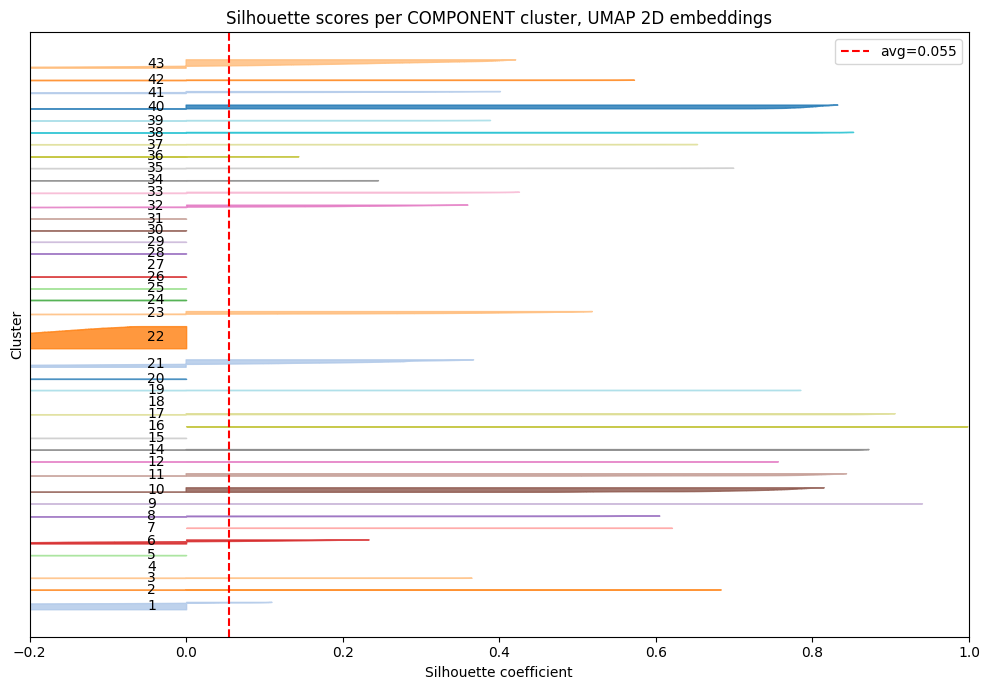

In [71]:
unique_clusters = np.unique(labels)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for cluster in unique_clusters:
    vals = np.sort(sample_sil[labels == cluster])
    size = vals.shape[0]
    y_upper = y_lower + size

    color = plt.cm.tab20(hash(cluster) % 20)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0, vals,
        facecolor=color, edgecolor=color, alpha=0.8
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(cluster), va='center')
    y_lower = y_upper + 10000  # gap between clusters

ax.axvline(x=silhouette_avg, color='red', linestyle='--', label=f'avg={silhouette_avg:.3f}')
ax.set_title('Silhouette scores per COMPONENT cluster, UMAP 2D embeddings')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.set_xlim([-0.2, 1.0])
ax.legend(loc='best')
plt.tight_layout()
plt.show()